# Predictive Modeling


**Input:** `data/processed/features_daily.csv`

**Output:** `outputs/figures/model_*.png`

**Models:** Ridge Regression, Random Forest, XGBoost


##### Evaluation Strategy

- Train on Oct 2022 – Oct 2024 (2 full annual cycles), test on Nov 2024 – Oct 2025 (1 full annual cycle). A full-year test set ensures every season is evaluated, avoiding the summer-only bias of an 80/20 cut.

- 5-fold TimeSeriesSplit: Each fold trains on all data before the test window. Early folds have insufficient seasonal coverage, so individual fold R² values are expected to be negative - this is a diagnostic, not the headline metric.


## Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
HAS_XGB = True


warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

features = pd.read_csv('data/processed/features_daily.csv', parse_dates=['date'])
features = features.sort_values('date').reset_index(drop=True)

TARGET = 'pct_respiratory'

LINEAR_FEATURES = [
    'temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14',
    'month_sin', 'month_cos', 'day_of_week', 'is_weekend',
]


TREE_FEATURES = [
    'temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14',
    'month', 'day_of_week', 'is_weekend', 'season_num',
]

X_linear = features[LINEAR_FEATURES].values
X_tree   = features[TREE_FEATURES].values
y        = features[TARGET].values
dates    = features['date'].values

print(f'Dataset: {features.shape[0]} rows')
print(f'Date range: {features["date"].min().date()} to {features["date"].max().date()}')
print(f'Target: {y.min():.2f}% - {y.max():.2f}%  (mean {y.mean():.2f}%)')
print(f'XGBoost available: {HAS_XGB}')


Dataset: 1119 rows
Date range: 2022-10-09 to 2025-10-31
Target: 7.09% - 26.58%  (mean 13.24%)
XGBoost available: True


We create 5 expanding folds, where each model trains on all past data and tests on the next ~6 months. Early folds have limited seasonal coverage—for example, Fold 1 trains only on fall/winter and tests on spring/summer, which forces the model to extrapolate.

In [ ]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

def cv_evaluate(model, X, y, cv, scale=False):
    """Time-series cross-validation. Returns per-fold DataFrame."""
    rows = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        model.fit(X_tr, y_tr)
        rows.append({
            'fold':      fold + 1,
            'n_train':   len(train_idx),
            'n_test':    len(test_idx),
            'train_r2':  r2_score(y_tr,  model.predict(X_tr)),
            'test_r2':   r2_score(y_te,  model.predict(X_te)),
            'test_rmse': np.sqrt(mean_squared_error(y_te, model.predict(X_te))),
            'test_mae':  mean_absolute_error(y_te, model.predict(X_te)),
        })

    df = pd.DataFrame(rows)
    hdr = f'  {"Fold":<5}  {"N train":>8}  {"N test":>7}  {"Train R²":>9}  {"Test R²":>8}  {"RMSE":>6}  {"MAE":>6}'
    print(hdr)
    print('  ' + '-' * 62)
    for _, r in df.iterrows():
        print(f'  {int(r.fold):<5}  {int(r.n_train):>8}  {int(r.n_test):>7}  '
              f'{r.train_r2:>9.3f}  {r.test_r2:>8.3f}  {r.test_rmse:>6.3f}  {r.test_mae:>6.3f}')
    print('  ' + '-' * 62)
    print(f'  {"Mean":<5}  {"":>8}  {"":>7}  '
          f'{df.train_r2.mean():>9.3f}  {df.test_r2.mean():>8.3f}  '
          f'{df.test_rmse.mean():>6.3f}  {df.test_mae.mean():>6.3f}')
    pm = '±'
    print(f'  {pm:<5}  {"":>8}  {"":>7}  '
          f'{df.train_r2.std():>9.3f}  {df.test_r2.std():>8.3f}  '
          f'{df.test_rmse.std():>6.3f}  {df.test_mae.std():>6.3f}')
    return df

all_cv   = {}   # fold-level DataFrames
all_summ = {}   # summary dicts for comparison table

---
## Model A - Ridge Regression


Ridge regression is used instead of OLS because temperature, NO₂, and ozone are highly correlated due to shared seasonal patterns; Ridge shrinks their coefficients to reduce overfitting while keeping all features. Month is encoded using month_sin and month_cos so December and January are treated as adjacent, allowing the model to capture smooth seasonal cycles. The regularization strength is automatically chosen by RidgeCV from [0.1, 1, 10, 100, 1000] using efficient leave-one-out cross-validation.

In [6]:
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])

print('Model A - Ridge Regression')
print(f'Features ({len(LINEAR_FEATURES)}): {LINEAR_FEATURES}')
print()
ridge_cv = cv_evaluate(ridge, X_linear, y, tscv, scale=True)

# Fit on full data for coefficient inspection
sc_full = StandardScaler()
ridge.fit(sc_full.fit_transform(X_linear), y)
print(f'\nSelected alpha: {ridge.alpha_:.1f}')

coef_df = (pd.DataFrame({'feature': LINEAR_FEATURES, 'coef': ridge.coef_})
             .assign(abs_coef=lambda d: d.coef.abs())
             .sort_values('abs_coef', ascending=False))
print('\nCoefficients (sorted by |coef|):')
for _, row in coef_df.iterrows():
    bar = '█' * int(row.abs_coef / coef_df.abs_coef.max() * 20)
    print(f'  {row.feature:<20}  {row.coef:>+7.4f}  {bar}')

all_cv['Ridge']   = ridge_cv
all_summ['Ridge'] = {
    'mean_r2':  ridge_cv.test_r2.mean(),
    'std_r2':   ridge_cv.test_r2.std(),
    'rmse':     ridge_cv.test_rmse.mean(),
    'mae':      ridge_cv.test_mae.mean(),
    'fold_r2':  ridge_cv.test_r2.tolist(),
}


Model A - Ridge Regression
Features (9): ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend']

  Fold    N train   N test   Train R²   Test R²    RMSE     MAE
  --------------------------------------------------------------
  1           189      186      0.679    -5.186   4.233   3.688
  2           375      186      0.776     0.466   2.265   1.811
  3           561      186      0.764    -0.513   1.328   1.032
  4           747      186      0.789     0.529   2.440   1.994
  5           933      186      0.773    -1.758   2.154   1.642
  --------------------------------------------------------------
  Mean                          0.756    -1.292   2.484   2.033
  ±                             0.044     2.366   1.067   0.993

Selected alpha: 10.0

Coefficients (sorted by |coef|):
  temperature           -1.4214  ████████████████████
  month_cos             +0.9891  █████████████
  no2_lag12             +0.8507  █

---
## Model B - Random Forest

- Random Forest is used because it can capture non-linear relationships and interactions that linear models cannot, such as seasonal effects where NO₂ relates differently to illness in winter versus summer. 
- The model controls overfitting by limiting tree depth (max_depth=8) and requiring a minimum number of samples per leaf (min_samples_leaf=10). It also improves generalization by using feature subsampling (max_features=0.6) to reduce correlation between trees. Using n_estimators=300 ensures stable performance and feature importance, with little benefit from adding more trees beyond this point.

In [7]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)

print('Model B - Random Forest')
print(f'Features ({len(TREE_FEATURES)}): {TREE_FEATURES}')
print()
rf_cv = cv_evaluate(rf, X_tree, y, tscv, scale=False)

# Fit on full data for feature importances
rf.fit(X_tree, y)
imp_df = (pd.DataFrame({'feature': TREE_FEATURES, 'importance': rf.feature_importances_})
            .sort_values('importance', ascending=False))
print('\nFeature importances (mean decrease in impurity):')
for _, row in imp_df.iterrows():
    bar = '█' * int(row.importance / imp_df.importance.max() * 25)
    print(f'  {row.feature:<20}  {row.importance:.4f}  {bar}')

all_cv['Random Forest']   = rf_cv
all_summ['Random Forest'] = {
    'mean_r2':    rf_cv.test_r2.mean(),
    'std_r2':     rf_cv.test_r2.std(),
    'rmse':       rf_cv.test_rmse.mean(),
    'mae':        rf_cv.test_mae.mean(),
    'fold_r2':    rf_cv.test_r2.tolist(),
    'importances': dict(zip(TREE_FEATURES, rf.feature_importances_)),
}


Model B - Random Forest
Features (9): ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month', 'day_of_week', 'is_weekend', 'season_num']

  Fold    N train   N test   Train R²   Test R²    RMSE     MAE
  --------------------------------------------------------------
  1           189      186      0.907    -3.407   3.573   3.288
  2           375      186      0.950     0.233   2.715   2.194
  3           561      186      0.905     0.271   0.922   0.739
  4           747      186      0.918     0.033   3.496   2.802
  5           933      186      0.867    -0.995   1.832   1.409
  --------------------------------------------------------------
  Mean                          0.909    -0.773   2.508   2.086
  ±                             0.030     1.560   1.132   1.030

Feature importances (mean decrease in impurity):
  temperature           0.4404  █████████████████████████
  ozone_lag13           0.2627  ██████████████
  month                 0.1004  █████
  no

---
## Model C - XGBoost

- XGBoost works by building trees one after another, where each new tree focuses on fixing the mistakes made by the previous ones. This step-by-step learning usually makes it more accurate than Random Forest on structured data like this. 
- A smaller learning rate (0.05) helps the model learn more carefully, while keeping trees shallow (max_depth=4) prevents it from overfitting. Subsampling rows and features adds extra stability, and 300 trees is enough for the model to learn well without unnecessary complexity.

In [9]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

print('Model C - XGBoost')
print(f'Features ({len(TREE_FEATURES)}): {TREE_FEATURES}')
print()
xgb_cv = cv_evaluate(xgb_model, X_tree, y, tscv, scale=False)

xgb_model.fit(X_tree, y)
ximp_df = (pd.DataFrame({'feature': TREE_FEATURES,
                            'importance': xgb_model.feature_importances_})
            .sort_values('importance', ascending=False))
print('\nFeature importances (gain):')
for _, row in ximp_df.iterrows():
    bar = '█' * int(row.importance / ximp_df.importance.max() * 25)
    print(f'  {row.feature:<20}  {row.importance:.4f}  {bar}')

all_cv['XGBoost']   = xgb_cv
all_summ['XGBoost'] = {
    'mean_r2':    xgb_cv.test_r2.mean(),
    'std_r2':     xgb_cv.test_r2.std(),
    'rmse':       xgb_cv.test_rmse.mean(),
    'mae':        xgb_cv.test_mae.mean(),
    'fold_r2':    xgb_cv.test_r2.tolist(),
    'importances': dict(zip(TREE_FEATURES, xgb_model.feature_importances_)),
}


Model C - XGBoost
Features (9): ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month', 'day_of_week', 'is_weekend', 'season_num']

  Fold    N train   N test   Train R²   Test R²    RMSE     MAE
  --------------------------------------------------------------
  1           189      186      1.000    -1.760   2.828   2.446
  2           375      186      0.998     0.065   2.997   2.365
  3           561      186      0.990    -0.056   1.110   0.875
  4           747      186      0.987    -0.102   3.732   3.008
  5           933      186      0.972    -0.734   1.708   1.329
  --------------------------------------------------------------
  Mean                          0.989    -0.517   2.475   2.005
  ±                             0.011     0.761   1.052   0.875

Feature importances (gain):
  temperature           0.3303  █████████████████████████
  ozone_lag13           0.1775  █████████████
  season_num            0.1739  █████████████
  month                 

---
## Cross-Validation Model Comparison

The table below summarizes mean CV performance across all 5 folds. Negative mean R² is expected in early folds (seasonal distribution shift - see Figure 3). The 80/20 holdout split in Figure 1 provides the primary performance estimate.


In [11]:
print(f'  {"Model":<16}  {"CV R² mean":>10}  {"± std":>7}  {"RMSE (pp)":>10}  {"MAE (pp)":>9}')
print('  ' + '-' * 58)
for name, s in all_summ.items():
    print(f'  {name:<16}  {s["mean_r2"]:>10.3f}  ±{s["std_r2"]:>6.3f}  '
          f'{s["rmse"]:>10.3f}  {s["mae"]:>9.3f}')

best_name = max(all_summ, key=lambda k: all_summ[k]['mean_r2'])
print(f'\nBest model: {best_name}  (CV R² = {all_summ[best_name]["mean_r2"]:.3f})')


  Model             CV R² mean    ± std   RMSE (pp)   MAE (pp)
  ----------------------------------------------------------
  Ridge                 -1.292  ± 2.366       2.484      2.033
  Random Forest         -0.773  ± 1.560       2.508      2.086
  XGBoost               -0.517  ± 0.761       2.475      2.005

Best model: XGBoost  (CV R² = -0.517)


RMSE and MAE are in percentage-point units (same scale as pct_respiratory). e.g., RMSE = 1.5 means predictions are on average 1.5 pp off the actual % of ED visits.

---
## Figure 1 - Primary Evaluation: Actual vs Predicted (Leave-Last-Year-Out Holdout)

- The model is trained on October 2022 – October 2024 (2 full annual cycles) and tested on November 2024 – October 2025 (1 full annual cycle, all 12 months). The test set spans fall → winter peak → spring → summer, so the R² is measured across all seasonal regimes.

- Dual time series (actual vs predicted). A line chart over the full date range shows not just accuracy but whether the model captures the shape, timing, and amplitude of seasonal peaks. The shaded regions distinguish training from test visually.



Primary Evaluation — Leave-Last-Year-Out Holdout
  Train: 2022-10-09 – 2024-10-31  (754 days)
  Test:  2024-11-01 – 2025-10-31  (365 days, all 12 months)

  Model              Test R²   RMSE (pp)   MAE (pp)
  --------------------------------------------------
  Ridge                0.687       2.394      1.880 <-- best
  Random Forest        0.570       2.806      2.126
  XGBoost              0.540       2.902      2.157

Best: Ridge  Test R² = 0.687  |  RMSE = 2.394 pp


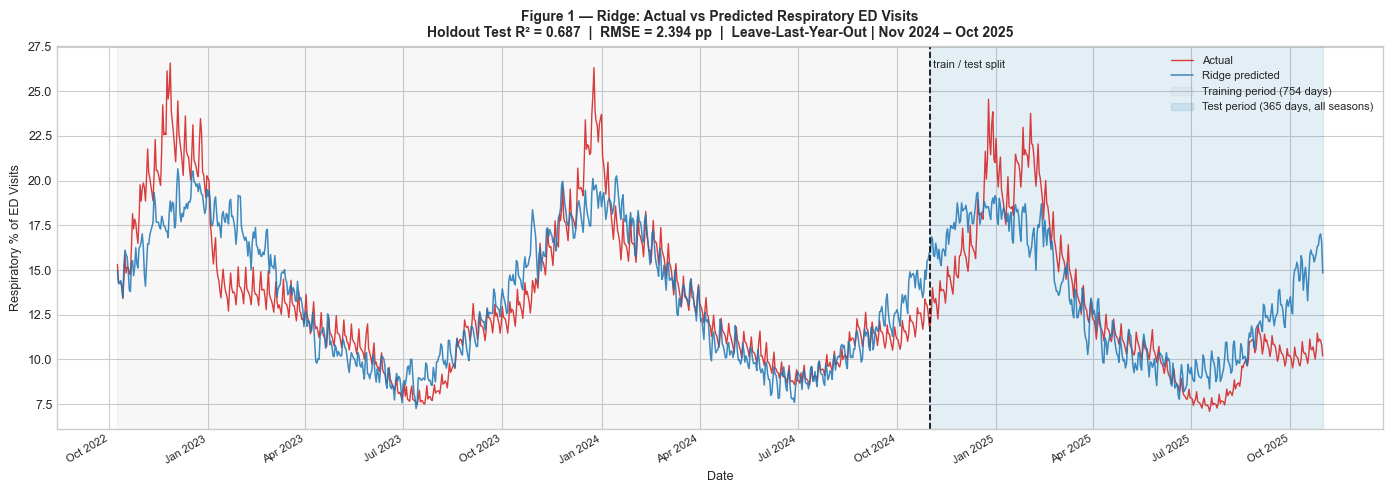

Saved: outputs/figures/model_01_actual_vs_predicted.png


In [13]:
# ── Primary evaluation: leave-last-year-out holdout ─────────────────────────
SPLIT_DATE = pd.Timestamp('2024-10-31')
split_idx  = features[features['date'] <= SPLIT_DATE].shape[0]
split_date = features['date'].iloc[split_idx - 1]

candidates = [
    ('Ridge',         X_linear),
    ('Random Forest', X_tree),
]
if HAS_XGB:
    candidates.append(('XGBoost', X_tree))

holdout = {}
for mname, X_feat in candidates:
    if mname == 'Ridge':
        clf   = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])
        sc80  = StandardScaler()
        X_tr  = sc80.fit_transform(X_feat[:split_idx])
        X_te  = sc80.transform(X_feat[split_idx:])
        X_all = sc80.transform(X_feat)
    elif mname == 'Random Forest':
        clf   = RandomForestRegressor(n_estimators=300, max_depth=8,
                    min_samples_leaf=10, max_features=0.6, random_state=42, n_jobs=-1)
        X_tr  = X_feat[:split_idx]
        X_te  = X_feat[split_idx:]
        X_all = X_feat
    else:
        clf   = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
        X_tr  = X_feat[:split_idx]
        X_te  = X_feat[split_idx:]
        X_all = X_feat

    clf.fit(X_tr, y[:split_idx])
    pred_te  = clf.predict(X_te)
    pred_all = clf.predict(X_all)
    holdout[mname] = {
        'r2':      r2_score(y[split_idx:], pred_te),
        'rmse':    np.sqrt(mean_squared_error(y[split_idx:], pred_te)),
        'mae':     mean_absolute_error(y[split_idx:], pred_te),
        'pred_all': pred_all,
    }

# Print comparison table
print('Primary Evaluation — Leave-Last-Year-Out Holdout')
print(f'  Train: {features["date"].iloc[0].date()} – {split_date.date()}  ({split_idx} days)')
print(f'  Test:  {features["date"].iloc[split_idx].date()} – {features["date"].iloc[-1].date()}  ({len(y)-split_idx} days, all 12 months)')
print()
r2_col = 'Test R²'
print(f'  {"Model":<16}  {r2_col:>8}  {"RMSE (pp)":>10}  {"MAE (pp)":>9}')
print('  ' + '-' * 50)
for mname, h in holdout.items():
    marker = ' <-- best' if mname == max(holdout, key=lambda k: holdout[k]['r2']) else ''
    print(f'  {mname:<16}  {h["r2"]:>8.3f}  {h["rmse"]:>10.3f}  {h["mae"]:>9.3f}{marker}')

best_ho   = max(holdout, key=lambda k: holdout[k]['r2'])
y_pred    = holdout[best_ho]['pred_all']
test_r2   = holdout[best_ho]['r2']
test_rmse = holdout[best_ho]['rmse']
print(f'\nBest: {best_ho}  Test R² = {test_r2:.3f}  |  RMSE = {test_rmse:.3f} pp')

# ── Figure 1 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

test_start = features['date'].iloc[split_idx]

ax.plot(features['date'], y,       color='#d62728', linewidth=1.0,
        label='Actual', alpha=0.9)
ax.plot(features['date'], y_pred,  color='#1f77b4', linewidth=1.1,
        label=f'{best_ho} predicted', alpha=0.85)

ax.axvspan(features['date'].iloc[0], split_date,
           alpha=0.06, color='gray', label=f'Training period ({split_idx} days)')
ax.axvspan(test_start, features['date'].iloc[-1],
           alpha=0.12, color='#1f77b4', label=f'Test period ({len(y)-split_idx} days, all seasons)')
ax.axvline(test_start, color='black', linewidth=1.2, linestyle='--')
ax.text(test_start, ax.get_ylim()[1] * 0.97, ' train / test split',
        fontsize=8, va='top')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Respiratory % of ED Visits', fontsize=9)
ax.set_xlabel('Date', fontsize=9)
ax.set_title(
    f'Figure 1 — {best_ho}: Actual vs Predicted Respiratory ED Visits\n'
    f'Holdout Test R² = {test_r2:.3f}  |  RMSE = {test_rmse:.3f} pp  |  '
    f'Leave-Last-Year-Out | Nov 2024 – Oct 2025',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/figures/model_01_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_01_actual_vs_predicted.png')


---
## Figure 2 - Feature Importance

Horizontal grouped bar chart (RF alongside XGBoost) - Feature importance quantifies which inputs the model relies on most. Horizontal bars are chosen because the feature names are long and would require rotation on a vertical axis. Showing RF and XGBoost side by side in the same figure makes it possible to verify that both models agree on the ranking, which increases confidence that the importance is real and not an artefact of one algorithm's internal metric.

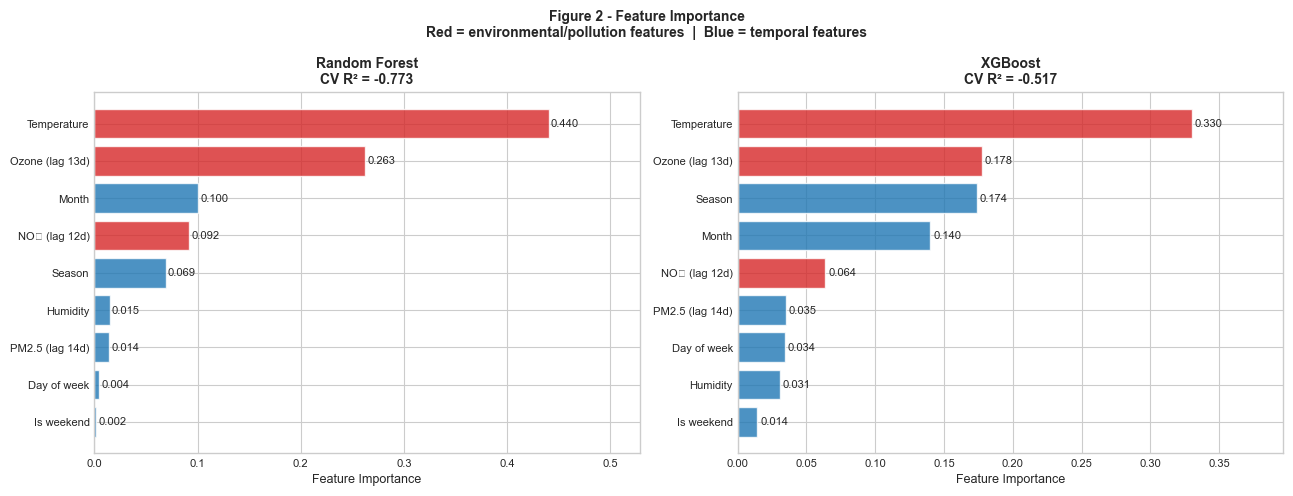

Saved: outputs/figures/model_02_feature_importance.png


In [15]:
if 'Random Forest' in all_summ and 'XGBoost' in all_summ:
    n_models = 2
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    model_items = [('Random Forest', all_summ['Random Forest']['importances']),
                   ('XGBoost',       all_summ['XGBoost']['importances'])]
else:
    n_models = 1
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    axes = [axes]
    model_items = [('Random Forest', all_summ['Random Forest']['importances'])]

FEAT_LABELS = {
    'temperature':  'Temperature',
    'humidity':     'Humidity',
    'no2_lag12':    'NO₂ (lag 12d)',
    'ozone_lag13':  'Ozone (lag 13d)',
    'pm25_lag14':   'PM2.5 (lag 14d)',
    'month':        'Month',
    'day_of_week':  'Day of week',
    'is_weekend':   'Is weekend',
    'season_num':   'Season',
}

for ax, (mname, imp_dict) in zip(axes, model_items):
    imp_s = pd.Series(imp_dict).rename(index=FEAT_LABELS).sort_values()
    colors = ['#d62728' if 'Temperature' in f or 'NO₂' in f or 'Ozone' in f
              else '#1f77b4' for f in imp_s.index]
    bars = ax.barh(imp_s.index, imp_s.values, color=colors, alpha=0.80, edgecolor='white')
    for bar, val in zip(bars, imp_s.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left', fontsize=8)
    ax.set_xlabel('Feature Importance', fontsize=9)
    ax.set_xlim(0, imp_s.max() * 1.20)
    ax.tick_params(axis='both', labelsize=8)
    ax.set_title(f'{mname}\nCV R² = {all_summ[mname]["mean_r2"]:.3f}',
                 fontsize=10, fontweight='bold')

fig.suptitle(
    'Figure 2 - Feature Importance\n'
    'Red = environmental/pollution features  |  Blue = temporal features',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/figures/model_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_02_feature_importance.png')


---
## Figure 3 - CV Fold R² Comparison

Grouped bar chart (one group per fold, one bar per model) - This chart proves the evaluation was done correctly. Showing R² for each fold separately makes it visible whether performance is consistent across time or degrades in specific seasons. A single summary number (mean R²) would hide this - a model with mean R² = 0.80 might achieve R² = 0.95 in winter folds and R² = 0.50 in summer folds, which a grouped bar chart would expose immediately.

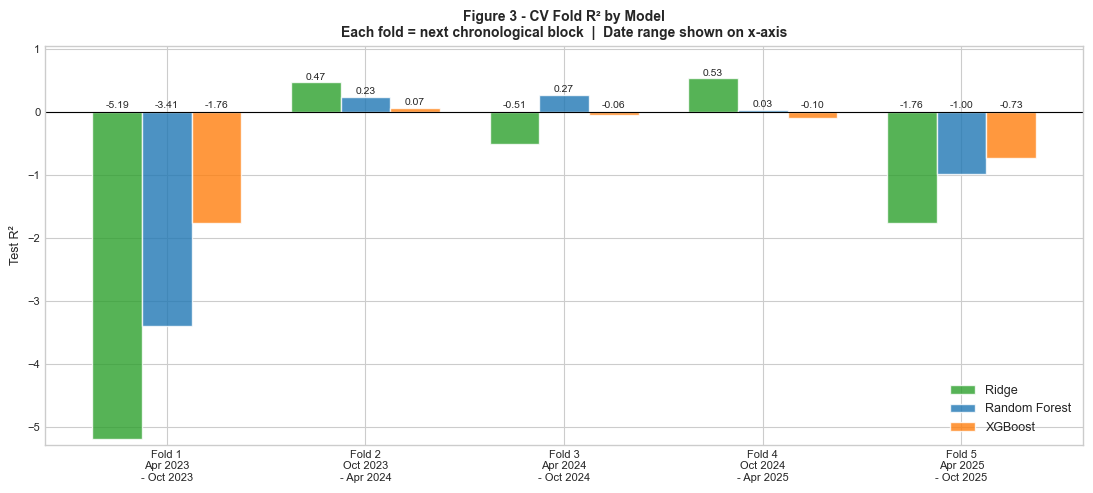

Saved: outputs/figures/model_03_cv_fold_r2.png


In [16]:
model_names = list(all_summ.keys())
n = len(model_names)
fold_labels = [f'Fold {i+1}' for i in range(N_SPLITS)]
x = np.arange(N_SPLITS)
width = 0.75 / n
colors_bar = ['#2ca02c', '#1f77b4', '#ff7f0e']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (mname, color) in enumerate(zip(model_names, colors_bar)):
    r2_vals = all_summ[mname]['fold_r2']
    offset  = (i - (n - 1) / 2) * width
    bars    = ax.bar(x + offset, r2_vals, width, label=mname,
                     color=color, alpha=0.80, edgecolor='white')
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                max(val + 0.01, 0.02),
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

# Show the approximate test date range for each fold
tscv_check = TimeSeriesSplit(n_splits=N_SPLITS)
fold_dates = []
for _, test_idx in tscv_check.split(X_tree):
    start = pd.Timestamp(dates[test_idx[0]]).strftime('%b %Y')
    end   = pd.Timestamp(dates[test_idx[-1]]).strftime('%b %Y')
    fold_dates.append(f'{start}\n- {end}')

ax.set_xticks(x)
ax.set_xticklabels([f'{fl}\n{fd}' for fl, fd in zip(fold_labels, fold_dates)],
                   fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Test R²', fontsize=9)
ax.set_ylim(min(min(s['fold_r2']) for s in all_summ.values()) - 0.1, 1.05)
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=9, loc='lower right')
ax.set_title(
    'Figure 3 - CV Fold R² by Model\n'
    'Each fold = next chronological block  |  Date range shown on x-axis',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/figures/model_03_cv_fold_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_03_cv_fold_r2.png')
